<a href="https://colab.research.google.com/github/HafidzShahab/Data-Science-2026/blob/main/pertemuan7_%5BAhmad_Hafidz%5D__%5B240401020180%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama  : Ahmad Hafidz
NIM   : 240401020180
kelas : IF 401

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [5]:
# Menentukan seed agar hasil random selalu sama saat dijalankan ulang
np.random.seed(42)

# Membuat 100 data luas rumah antara 50 sampai 200 m²
luas_rumah = np.random.randint(50, 200, 100).reshape(-1, 1)

# Membuat harga rumah berdasarkan rumus: Harga = 5 * Luas + Noise (Variasi acak)
# Misal: Rumah 100 m² harganya sekitar 500 juta + variasi
harga_rumah = 5 * luas_rumah.flatten() + np.random.normal(0, 50, 100)

# Menggabungkannya ke dalam DataFrame Pandas agar rapi
data = pd.DataFrame({'Luas_m2': luas_rumah.flatten(), 'Harga_Juta': harga_rumah})
print("5 Data Pertama:")
print(data.head())

5 Data Pertama:
   Luas_m2  Harga_Juta
0      152  782.894254
1      142  625.785631
2       64  336.342261
3      156  775.944052
4      121  628.389738


In [10]:


# Memastikan X berbentuk 2D array (DataFrame) dan y berbentuk 1D array (Series/vektor)
X = data[['Luas_m2']].values  # Mengambil nilai array 2D
y = data['Harga_Juta'].values  # Mengambil nilai array 1D

# Membagi data: 80% untuk training, 20% untuk testing
# Tambahkan stratifikasi/random_state yang konsisten
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Ukuran Data Train:", X_train.shape)
print("Ukuran Data Test:", X_test.shape)

Ukuran Data Train: (80, 1)
Ukuran Data Test: (20, 1)


In [12]:
# 1. Inisialisasi model Regresi Linear
model = LinearRegression()

# 2. Melatih model dengan data training
model.fit(X_train, y_train)

# 3. Menampilkan parameter yang ditemukan oleh model (Garis Regresi)
print("\n=== PARAMETER MODEL ===")
print(f"Coefficient (Slope/Kemiringan m): {model.coef_[0]:.2f}")
print(f"Intercept (Konstanta c): {model.intercept_:.2f}")
print(f"Persamaan Garis: Harga = {model.coef_[0]:.2f} * Luas + {model.intercept_:.2f}")


=== PARAMETER MODEL ===
Coefficient (Slope/Kemiringan m): 5.04
Intercept (Konstanta c): -3.94
Persamaan Garis: Harga = 5.04 * Luas + -3.94


In [14]:

# 1. Memprediksi harga rumah untuk data uji (X_test)
y_pred = model.predict(X_test)

# 2. Menghitung metrik evaluasi sesuai materi
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# 3. Menampilkan hasil evaluasi dengan format string yang benar
print("\n=== METRIK EVALUASI MODEL ===")
print(f"Mean Absolute Error (MAE): {mae:.2f} Juta")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} Juta")
print(f"R-Squared (R²): {r2:.4f}")


=== METRIK EVALUASI MODEL ===
Mean Absolute Error (MAE): 42.51 Juta
Mean Squared Error (MSE): 2636.70
Root Mean Squared Error (RMSE): 51.35 Juta
R-Squared (R²): 0.9380


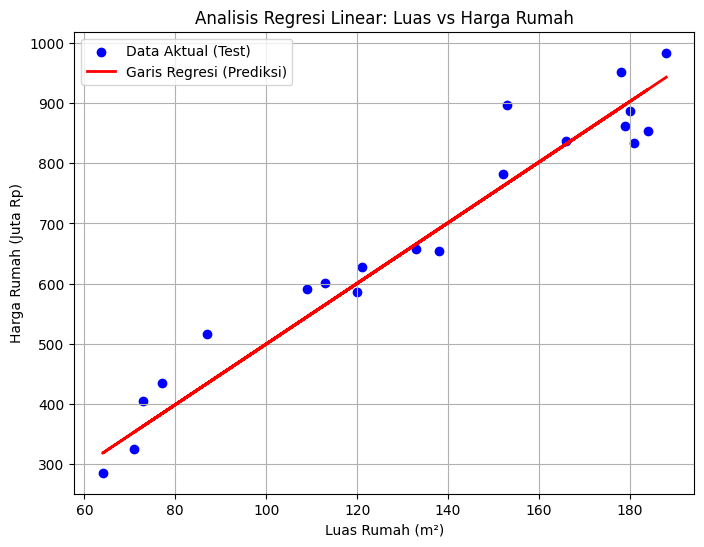

In [15]:
plt.figure(figsize=(8, 6))

# 1. Menggambar titik data aktual (Scatter Plot)
# Menggunakan X_test karena data berbentuk array hasil Langkah 3
plt.scatter(X_test, y_test, color='blue', label='Data Aktual (Test)')

# 2. Menggambar garis prediksi (Linear Regression Line)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Garis Regresi (Prediksi)')

# 3. Mengatur kelengkapan grafik
plt.title('Analisis Regresi Linear: Luas vs Harga Rumah')
plt.xlabel('Luas Rumah (m²)')
plt.ylabel('Harga Rumah (Juta Rp)')
plt.legend()
plt.grid(True)

# 4. Menampilkan grafik ke layar
plt.show()

Kesimpulan

1. Lanskap Machine Learning (ML)Supervised Learning: Model belajar dari data yang sudah memiliki target/label pasti (seperti belajar dengan kunci jawaban).Regresi: Sub-kategori supervised learning yang digunakan khusus untuk memprediksi nilai berupa angka kontinu (misal: harga rumah, suhu, gaji), bukan kategori/klasifikasi.2. Konsep Regresi LinearTujuan: Mencari garis lurus terbaik (paling mendekati titik data asli) untuk menggambarkan hubungan antara variabel input ($X$) dan target ($y$).Persamaan: Memanfaatkan rumus matematika $\hat{y} = \beta_{0} + \beta_{1}x$, di mana model bertugas mencari nilai intercept ($\beta_{0}$) dan slope/kemiringan ($\beta_{1}$) yang paling optimal.3. Proses Optimasi ModelCost Function (MSE): Menggunakan Mean Squared Error sebagai tolok ukur internal untuk menghitung seberapa besar eror/kesalahan prediksi model saat latihan.Gradient Descent: Algoritma optimasi yang digunakan model untuk meminimalkan eror tersebut secara bertahap dengan mengatur parameter garis berdasarkan Learning Rate ($\alpha$) yang tepat.4. Metrik Evaluasi RegresiUntuk menguji performa model setelah dilatih, digunakan 4 metrik utama:MAE: Rata-rata kesalahan absolut. Mudah dipahami karena satuannya sama dengan data asli dan kebal terhadap pencilan (outlier).MSE: Rata-rata kesalahan kuadrat. Baik untuk fungsi internal training, tetapi satuannya sulit diinterpretasikan karena dikuadratkan.RMSE: Akar dari MSE. Satuan kembali normal, paling sering digunakan untuk pelaporan ilmiah karena memberikan penalti tegas pada eror yang besar (outlier). Interpretasinya harus selalu relatif terhadap skala data asli.$R^2$ (R-Squared): Skor skala 0-1 untuk melihat seberapa baik variabel input mampu menjelaskan variasi target. Semakin mendekati 1 artinya model semakin akurat (fit).5. Alur Kerja Praktis (Scikit-Learn)Proses implementasi regresi linear di Python selalu mengikuti standarisasi 4 tahap utama:Instantiate: Menginisialisasi cetakan model (LinearRegression()).Fit: Melatih model dengan data latih (.fit()).Predict: Membuat prediksi pada data uji (.predict()).Evaluate: Mengukur tingkat keakuratan hasil menggunakan metrik evaluasi.